In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

# SIRT - Choice of Stopping Point

This notebook demonstrates choice of stopping point for the SIRT algorithm.

In [1]:
import os

import warnings
warnings.filterwarnings("ignore")

from cil.utilities.display import show2D
from cil.processors import Slicer
from cil.plugins.astra import ProjectionOperator
from cil.optimisation.algorithms import SIRT
from cil.optimisation.functions import IndicatorBox
from cil.optimisation.utilities.callbacks import ProgressCallback

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.stopping_rules import SharpnessCallback
from utils.lego_man import get_sharpness_slicers, calculate_metrics, make_bar_plots
from matplotlib import pyplot as plt

from cil.optimisation.utilities import callbacks
from utils.stopping_rules import calculate_sharpness, SavingCallback, SharpnessCallbackThreshold

import numpy as np
from cil.framework import DataContainer
from cil.utilities.jupyter import islicer
from cil.utilities.display import show1D


## Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.

You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [2]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=100*10**-4)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=100*10**-4)

In [3]:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full_slice.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)


In this notebook we'll be using Golden Angle data with 50% of the number of projections acquired in the full equidistant scan:

In [4]:
gr_scale = 0.5 # Here we look at the 50% case, but you could alter this at different cases.
gr_slice = Slicer(roi={'angle': (0, 457 * gr_scale), 'vertical': (317, 318)})(gr_full)
gr_slices_fbp = run_weighted_fbp_parallel(gr_slice) 

## SIRT Parameters

The key parameters to SIRT are the:
- constraint
- number of iterations

Here we apply a non-negativity constraint. The impact of this constraint was outlined in Golden_Angle_02_SIRT.ipynb.

SIRT exhibits semi-convergence, meaning that it approaches the ground truth up to a point and then further iterations cause the solution to become more noisy, diverging from the ground truth. This means the number of iterations plays the role of a regularisation parameter, and we can't use convergence of the algorithm as a stopping point.

### Setup the SIRT-NN algorithm

In [5]:
thresholds = [0.2, 0.25, 0.35] 

A = ProjectionOperator(gr_slice.geometry.get_ImageGeometry(), gr_slice.geometry)
ig = gr_slice.geometry.get_ImageGeometry()

sirt_nn = SIRT(operator=A, data=gr_slice, constraint=IndicatorBox(lower=0))
sirt_nn.update_objective_interval = 10

We run each algorithm for a maximum of 800 iterations:

In [6]:
iteration_nums = 800
sirt_callback = SharpnessCallbackThreshold(get_sharpness_slicers(), thresholds=thresholds)
saving_callback = SavingCallback(step=50)
sirt_nn.run(iteration_nums, callbacks=[ProgressCallback(), sirt_callback, saving_callback])

  0%|          | 0/800 [00:00<?, ?it/s]

Above, we also used a callback - SavingCallback -  to save the solution every 50 iterations.

Here we can use the slider to look at a zoomed region in each of the solutions. Looking at the images visually like this or comparing using metrics or line profiles is one way we could pick the number of iterations:

In [7]:
# Stack the saved solutions into a numpy array
array = np.stack([sol.array for sol in saving_callback.saved_solutions], axis=0)

dc = DataContainer(array[:, 110:350, 100:300], dimension_labels=tuple(['Iteration']) + equi_full_recon.geometry.dimension_labels)

islicer(dc, title=tuple(['Iteration: ' + str(p*50)  + ', index: ' for p in range(0,array.shape[0])]))

We see that early on e.g. at 50 iterations, the algorithm is too far from convergence - the image is very blurry and we don't have enough iterations.
As we increase the number of iterations we see less blur.

But after a point we see more and more noise being introduced, especially from 400 onwards.

Where would you choose to stop?


With this example we are focussing on reconstructing a single slice of the data, but if we were reconstructing a full 3D dataset we'd want to look at multiple slices throughout the volume when making this choice.

## Convergence

Remember, we don't want to wait until SIRT has converged before stopping. But it may be useful to check the plot of the objective value to see how close to convergence we are at our chosen point.

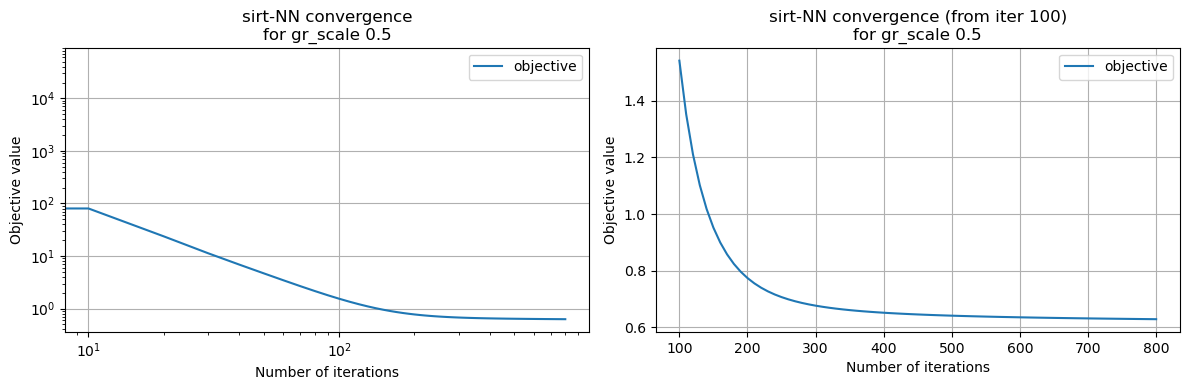

In [8]:
sirt_algo = sirt_nn

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(sirt_algo.iterations, sirt_algo.objective)
axes[0].legend(['objective'])
axes[0].grid()
axes[0].set_xlabel('Number of iterations')
axes[0].set_ylabel('Objective value')
axes[0].set_title(f'sirt-NN convergence\nfor gr_scale {gr_scale}')

axes[1].plot(sirt_algo.iterations[10:], sirt_algo.objective[10:])
axes[1].legend(['objective'])
axes[1].grid()
axes[1].set_xlabel('Number of iterations')
axes[1].set_ylabel('Objective value')
axes[1].set_title(f'sirt-NN convergence (from iter 100)\nfor gr_scale {gr_scale}')

plt.tight_layout()
plt.show()


## Sharpness Stopping Rule

This paper: "Warnett, Jason. (2024). "Don't stop me now!": Stopping rules for iterative reconstruction with dimensional X-ray Computed Tomography. 10.13140/RG.2.2.22554.45766."

 demonstrates different ways to choose the stopping point for SIRT. Of the stopping rules in the paper, the Sharpness Stopping Rule was one of the most effective.

Above, when we run SIRT we used a callback which applies this stopping rule for an input list of threshold values. Here we'll explain how it works...



The Sharpness Stopping Rule takes in a list of 1D arrays.

These 1D arrays are rows in the image which we have chosen, where there is a boundary between two different materials.

The sharpness of this boundary is calculated to be the number of pixels it takes to go from 10% of the maximum value to 90% of the maximum value (the max is the mean of the highest values).

The algorithm is stopped when the sharpness of all of the boundaries has been stable for at least x% of iterations where x is threshold*100. 

Below we show a couple of these 1D arrays in the full equidistant data, you can change which index of the list to show, to see different ones:

In [9]:
arrays_1D = [slicer(equi_full_recon) for slicer in get_sharpness_slicers()]


This array is a boundary between air on the left, and the lego man's head on the right

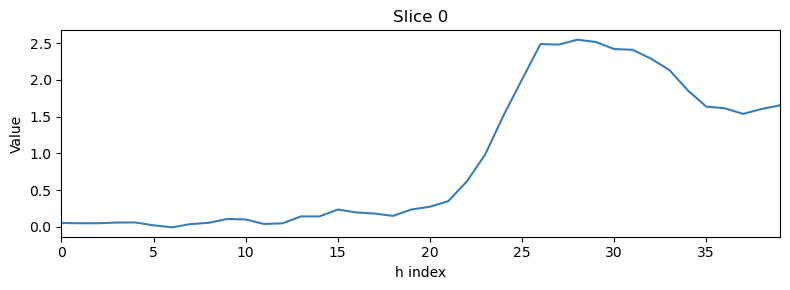

In [10]:
show1D(arrays_1D[0], title='Slice 0')

This array is a boundary between air in the middle of the lego man's head (left) and lego on the right:


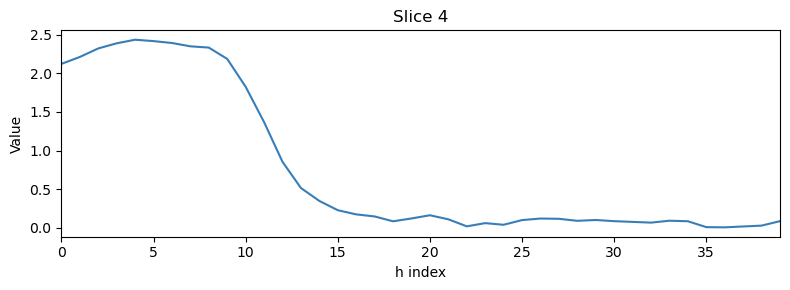

In [11]:
show1D(arrays_1D[4], title='Slice 4')

A downside to the sharpness stopping method is having to define these boundaries to measure sharpness on!

In this notebook we use a callback which saves what the stopping point would be if we had different values of the threshold.
The 'Don't Stop Me Now' paper suggests a threshold of 0.25

We tried: [0.2, 0.25, 0.35] 

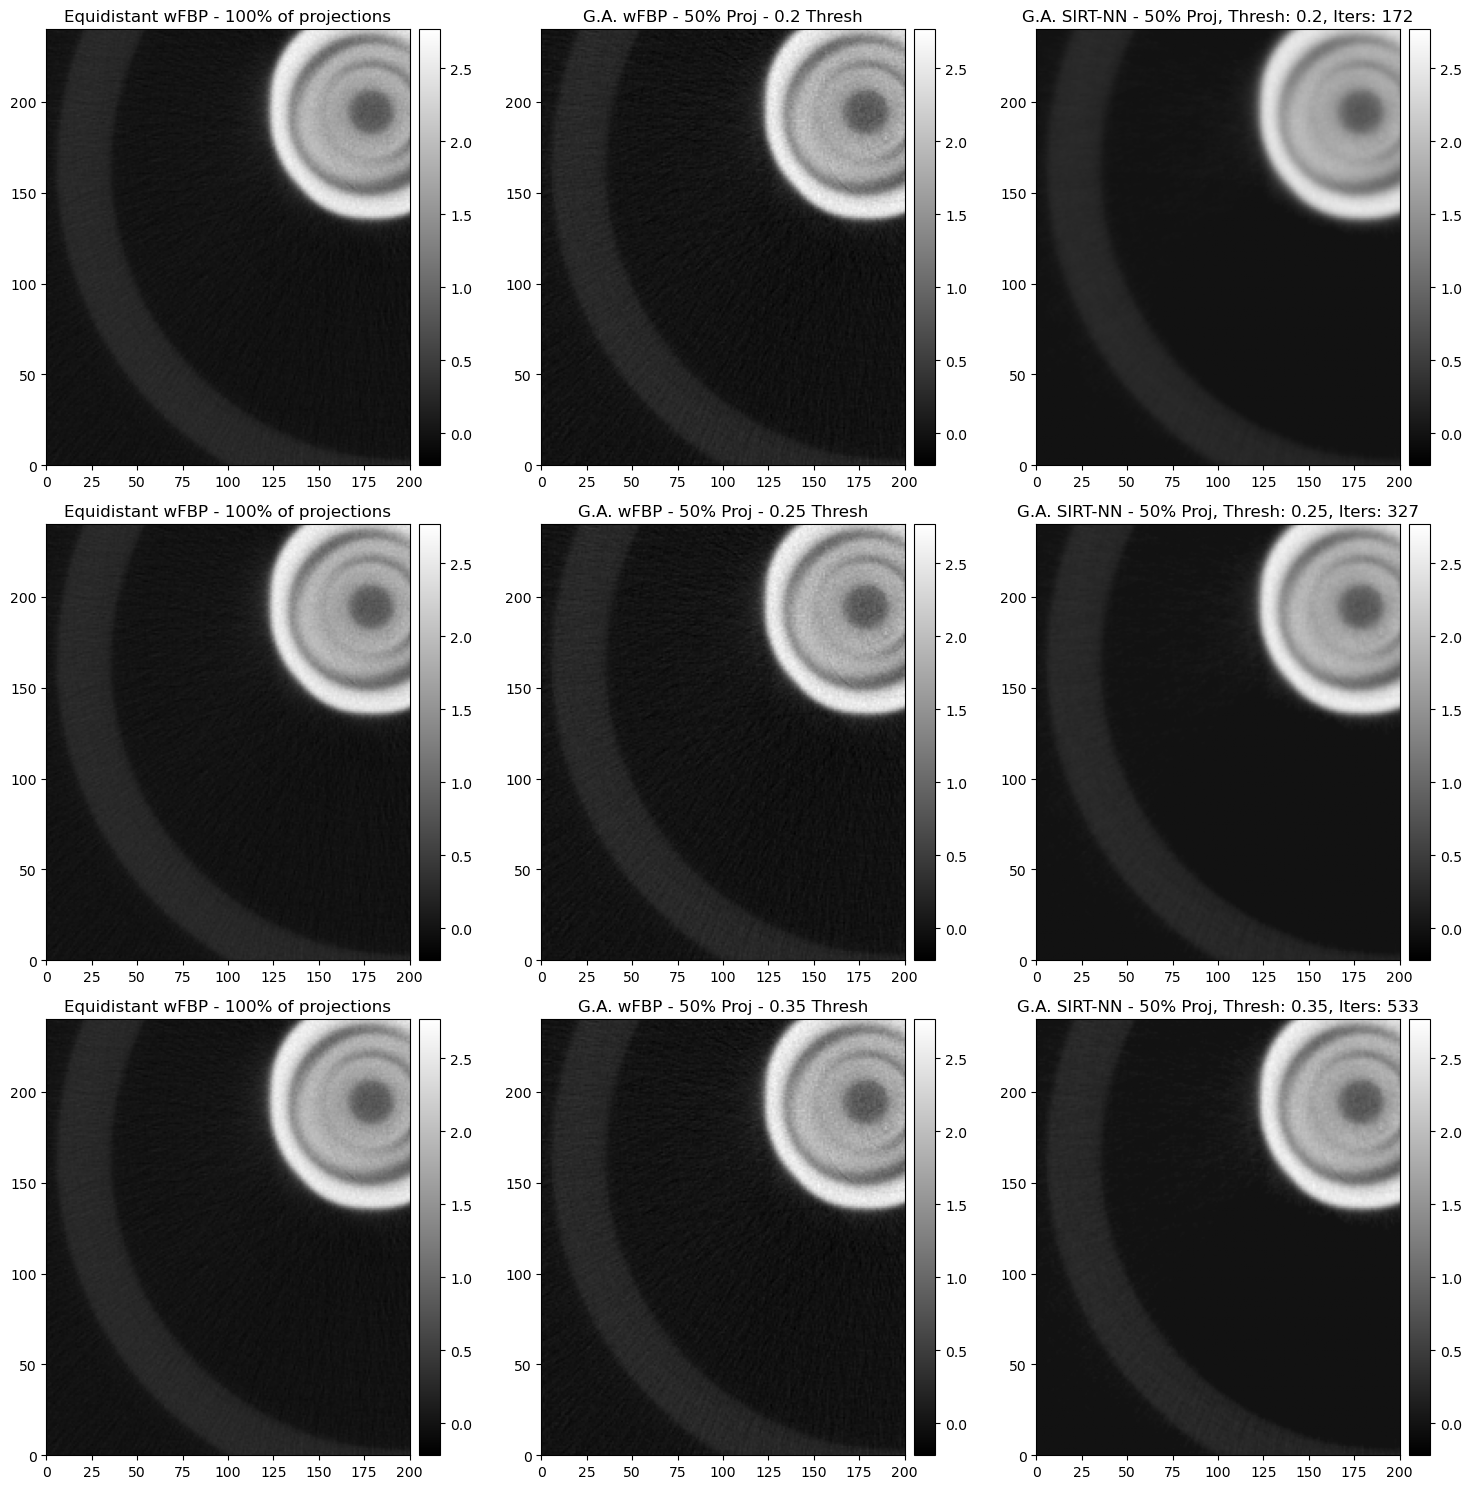

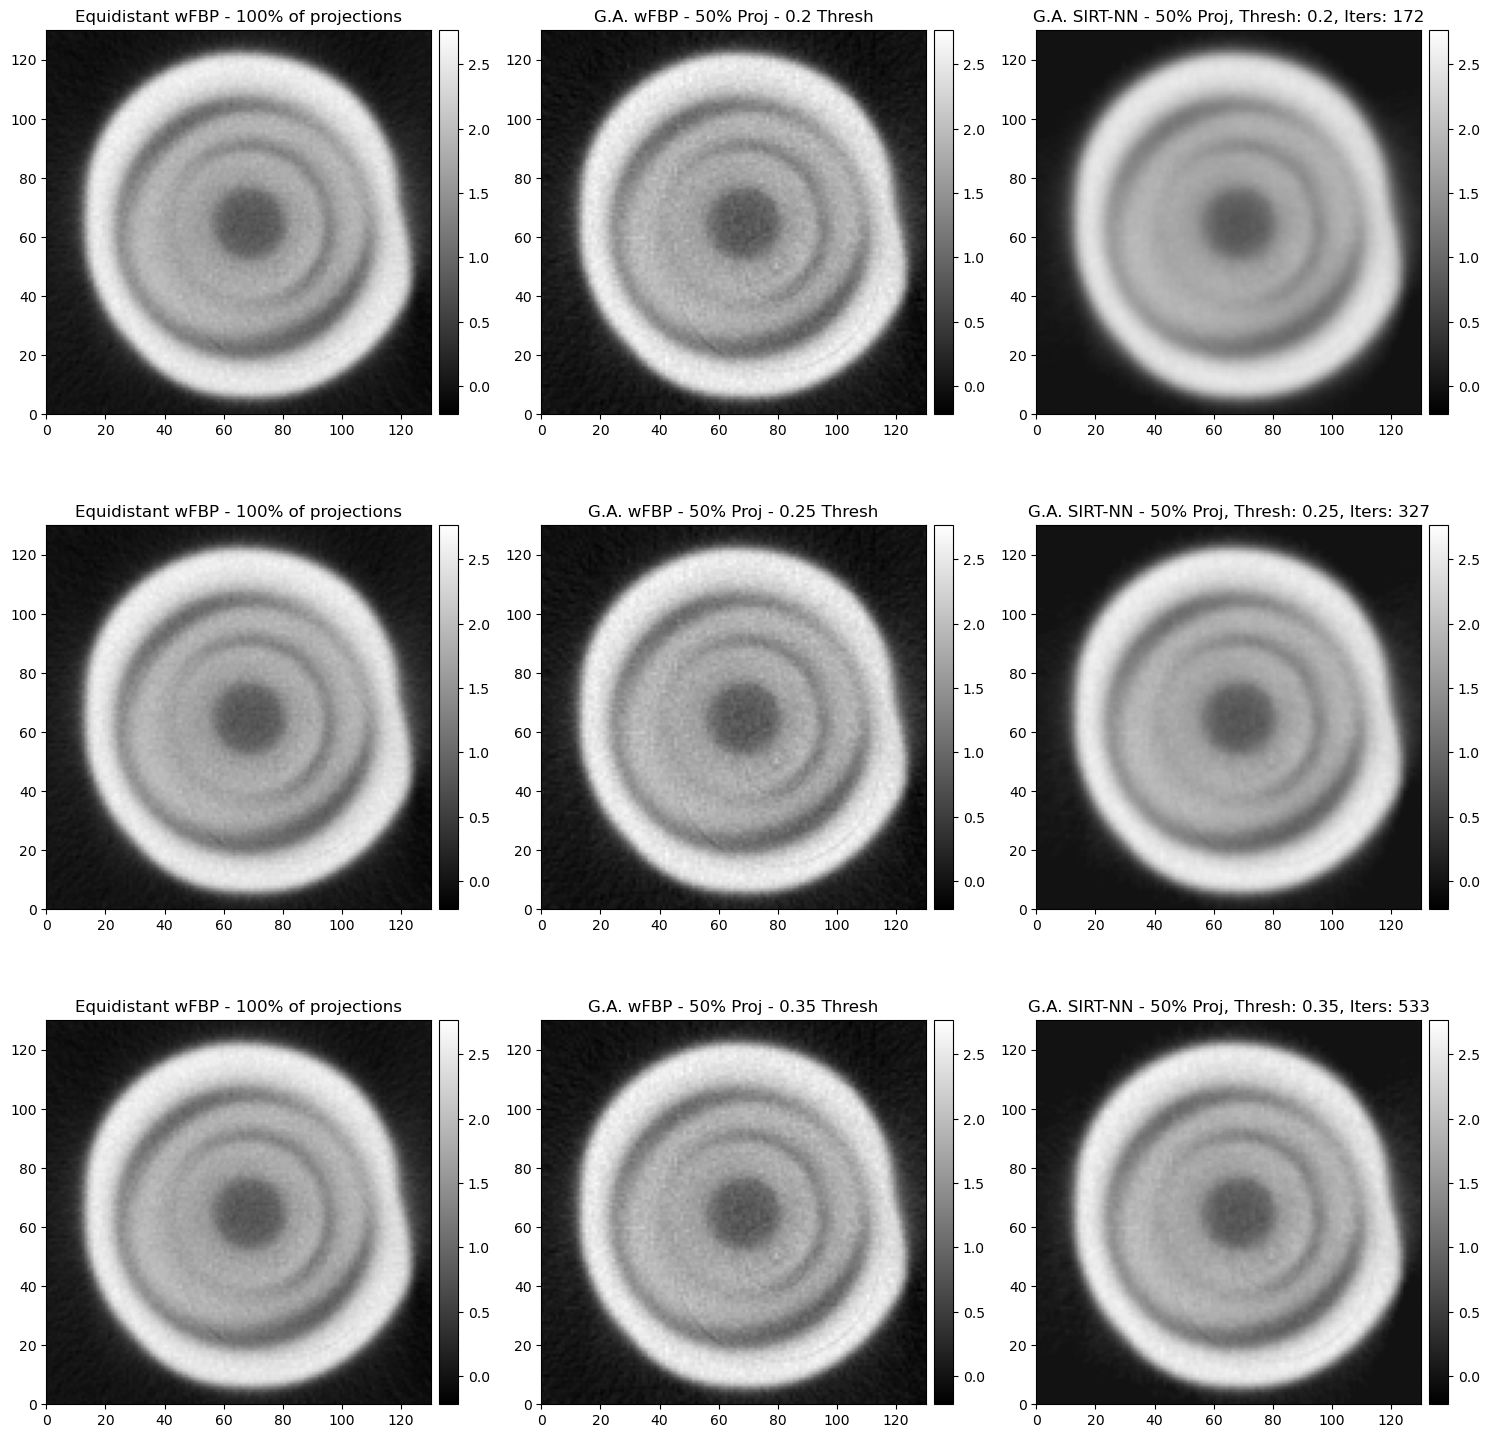

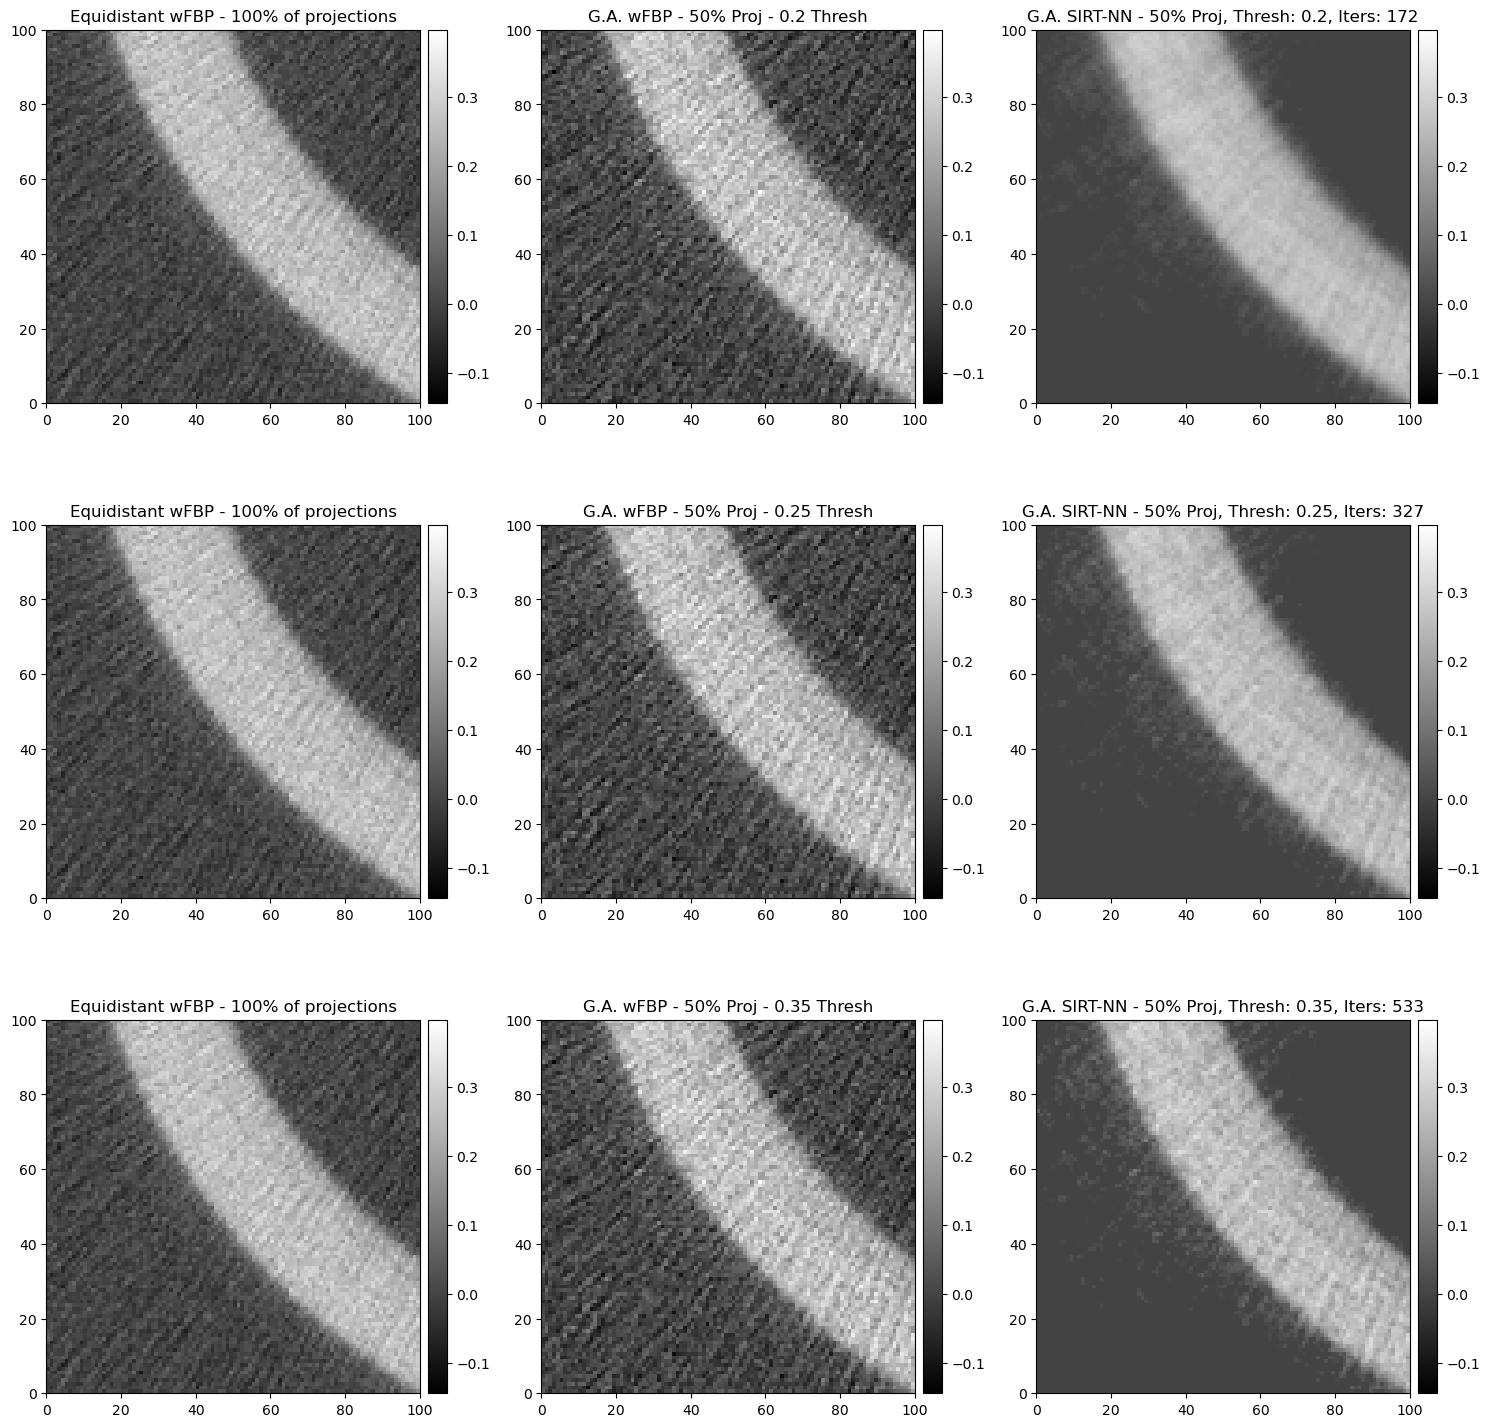

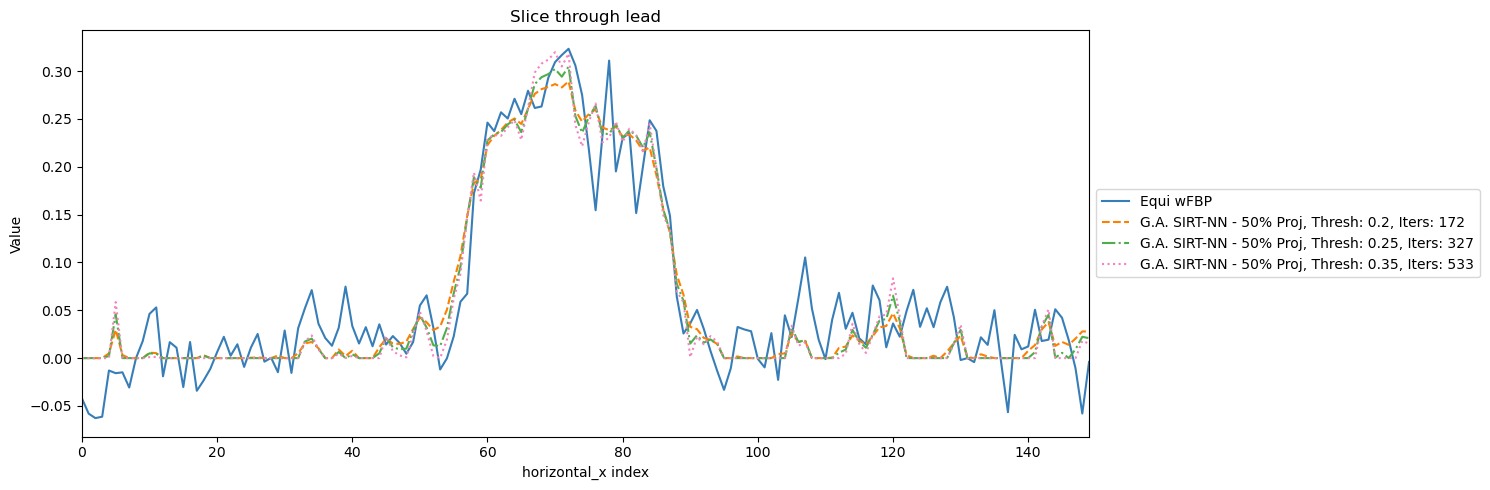

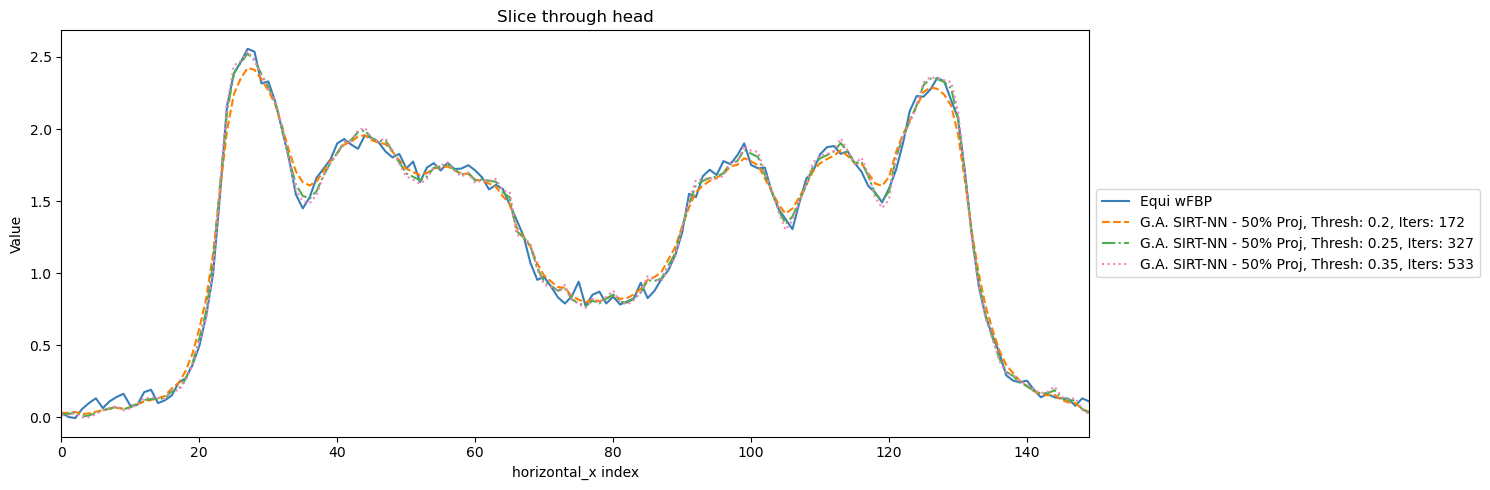

In [12]:
show1d_slicer_lead = Slicer(roi={'horizontal_x':(50,200)})
show1d_slicer_head = Slicer(roi={'horizontal_x':(200,350)})

def make_zoomed_plots(gr_scale, algo, callback):

    sirt_results = callback.threshold_solutions
    # check what indices are not None in sirt_results and only plot those
    valid_indices = [i for i, res in enumerate(sirt_results) if res is not None]
    sirt_results = [sirt_results[i] for i in valid_indices]
    threshold_points = [thresholds[i] for i in valid_indices]


    sirt_titles = [f"G.A. {algo.upper()} - {gr_scale*100:.0f}% Proj, Thresh: {th}, Iters: {sirt_callback.threshold_values[i]}" for i, th in enumerate(threshold_points)]

    fbp_titles = [f"G.A. wFBP - {gr_scale*100:.0f}% Proj - {th} Thresh" for th in threshold_points]
    fbp_results = [gr_slices_fbp]*len(threshold_points)
    images = []
    titles = []
    zoomed_equi_recon = equi_full_recon
    for sirt_img, sirt_title, fbp_img, fbp_title in zip( sirt_results, sirt_titles, fbp_results, fbp_titles):
        images.extend([zoomed_equi_recon,fbp_img, sirt_img])
        titles.extend([f"Equidistant wFBP - 100% of projections", fbp_title, sirt_title])

    

    # min is min of all images, max is max of all images
    vmin = min(img.min() for img in images)
    vmax = max(img.max() for img in images)

    show2D([x.array[110:350, 100:300] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

    show2D([x.array[240:370, 210:340] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

    data_lead = [x.array[110:210, 100:200] for x in images]
    mn = min(x.min() for x in data_lead)
    mx = max(x.max() for x in data_lead)
    show2D(data_lead, title=titles, cmap='gray', fix_range=(mn, mx), num_cols=3)

    results_list = [equi_full_recon] + sirt_results
    _titles= ['Equi wFBP'] + sirt_titles

    show1D([show1d_slicer_lead(x) for x in results_list], slice_list=[('horizontal_y', 300)], dataset_labels=_titles, title="Slice through lead", size=(15,5))
    show1D([show1d_slicer_head(x) for x in results_list], slice_list=[('horizontal_y', 300)], dataset_labels=_titles, title="Slice through head", size=(15,5))


def plot_sharpness(gr_scale, algo, callback):
    sharpness_values = callback.save_values

    plt.figure(figsize=(10, 5))
    for key, value in sharpness_values.items():
        plt.plot(value, label=f'Slice: {key}')

    for i, iters in enumerate(callback.threshold_values):
        plt.axvline(x=iters, linestyle='--', label=f'Stopping Point Iter: {iters} (Th: {thresholds[i]})')
    plt.xlabel('Iteration')
    plt.ylabel('Sharpness')
    plt.title(f'Sharpness Values for G.A. {algo.upper()} - {gr_scale*100:.0f}% Proj')
    plt.legend()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()



make_zoomed_plots(gr_scale, 'SIRT-NN', sirt_callback)



With threshold 0.2, we see that in the line profile through the head, we see less of a dip in the air gaps between the layers of the lego head.
With threshold 0.35 we see increased noise, both in the images and line profile through the lead.

Lets take a look at what happened to the sharpness values for each of the 1D arrays input:

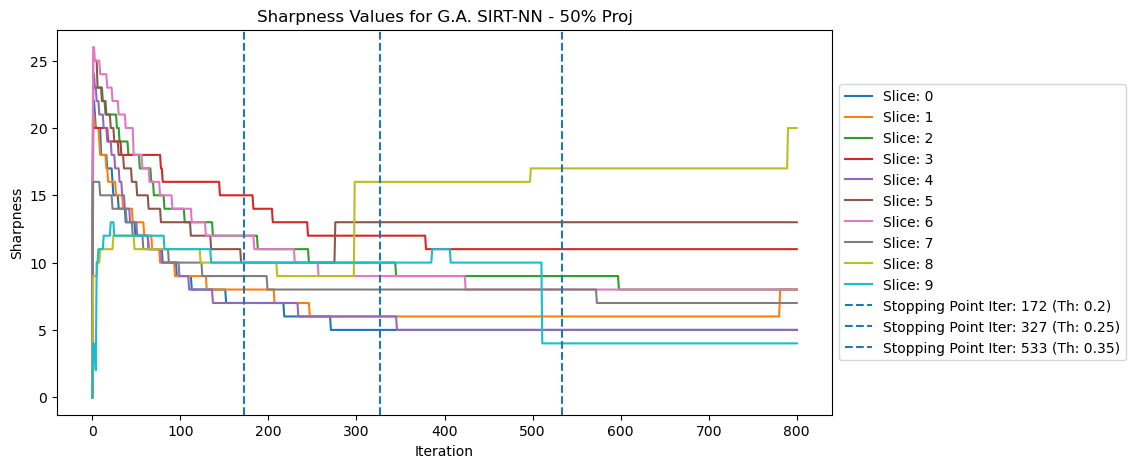

In [13]:
plot_sharpness(gr_scale, 'SIRT-NN', sirt_callback)

Let's look at the metrics:

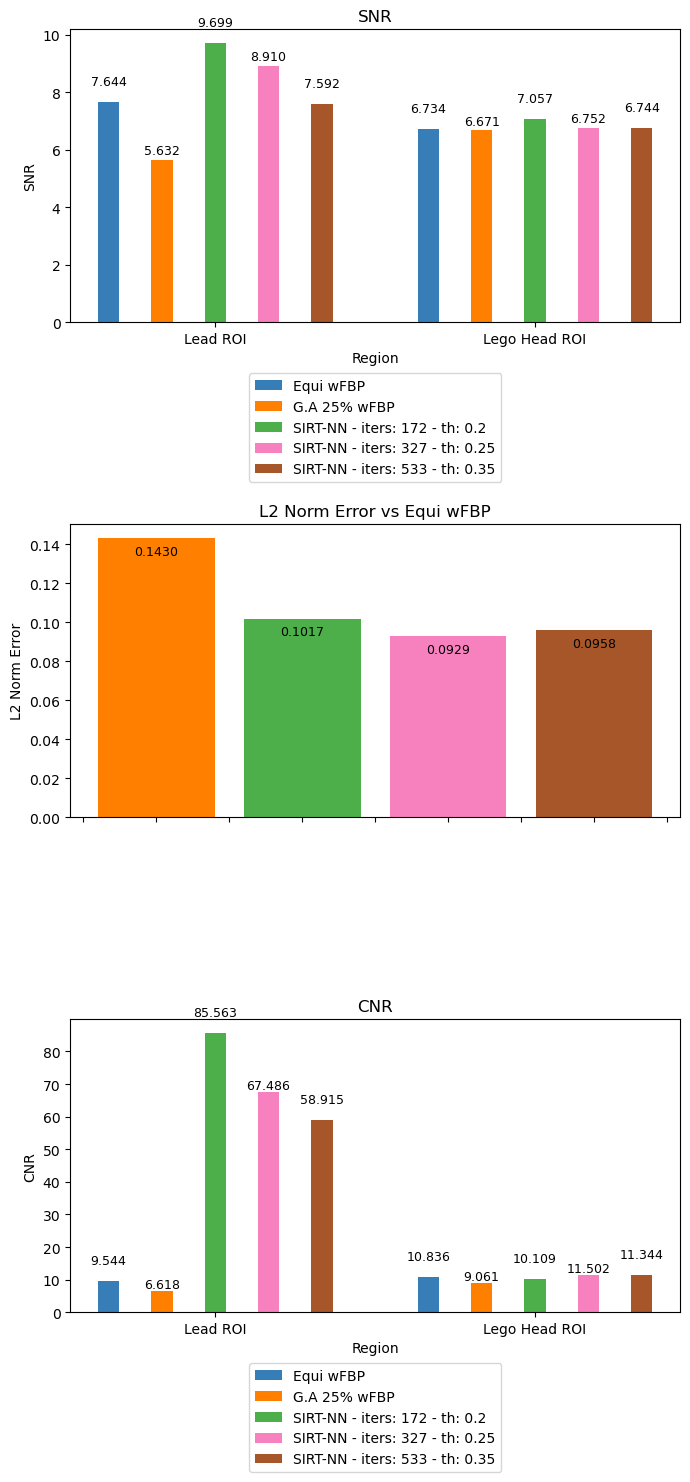

In [14]:
data = [gr_slices_fbp] + sirt_callback.threshold_solutions
_titles= ['Equi wFBP', 'G.A 25% wFBP'] + [f"SIRT-NN - iters: {sirt_callback.threshold_values[i]} - th: {thresholds[i]}" for i in range(len(thresholds))]
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner  = calculate_metrics(equi_full_recon, data)
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, _titles, orientation='vertical')

On balance, the 0.25 threshold recommended by the 'Don't Stop Me Now' paper seems a reasonable choice with this data. Therefore this is the threshold that was applied to choose the stopping point in Golden_Angle_02_SIRT.ipynb.

Note: We checked for different scales of the data (0.25, 0.5, 0.75), some more thresholds, and for SIRT without negativity as well.